<a href="https://colab.research.google.com/github/santana-robledo/Posgrado_Robotica_e_Inteligencia_Artificial/blob/main/Sistemas%20Inteligentes%20II/Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Josue Santana Robledo Corona

In [172]:
# Paquetería básica
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Importamos Tensorflow y Keras
import tensorflow as tf
from tensorflow import keras

# Usamos funcionalidades básicas de Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [173]:
!wget -O Housing.csv https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/Housing.csv

--2026-03-09 18:31:52--  https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/Housing.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29981 (29K) [text/plain]
Saving to: ‘Housing.csv’

Housing.csv         100%[===================>]  29.28K  --.-KB/s    in 0.003s  

2026-03-09 18:31:52 (11.0 MB/s) - ‘Housing.csv’ saved [29981/29981]



In [174]:
dataset = pd.read_csv("Housing.csv")
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [175]:
dataset.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [176]:
dataset.isin(['?', 'NA', 'N/A', '-']).sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [177]:
dataset = pd.get_dummies(dataset, columns=['furnishingstatus'])

In [178]:
x = dataset[['area','bedrooms','bathrooms','stories',
             'mainroad','guestroom','basement','prefarea',
             'hotwaterheating','airconditioning','parking',
             'furnishingstatus_furnished',
             'furnishingstatus_semi-furnished',
             'furnishingstatus_unfurnished']].copy()

y = np.log(dataset['price']).values

yn_cols = [
    'mainroad','guestroom','basement',
    'hotwaterheating','airconditioning','prefarea'
]

for c in yn_cols:
    x[c] = x[c].map({'yes':1,'no':0})

x = StandardScaler().fit_transform(x)

print(x.shape)
print(y.shape)

(545, 14)
(545,)


In [179]:
xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=0.2, random_state=42
)
print(xtrain.shape)
print(xtest.shape)

(436, 14)
(109, 14)


In [180]:
def build_model():

    model = keras.Sequential([
        keras.layers.Dense(32, activation='relu', input_shape=[x.shape[1]]),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1,activation='linear')
    ])

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae', tf.keras.metrics.R2Score()]
    )

    return model

In [181]:
model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_51 (Dense)                │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

In [182]:
history = model.fit(
    xtrain, ytrain,
    batch_size=32,
    epochs=300,
    validation_data=(xtest, ytest),
    verbose=1
)

Epoch 1/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 236.9456 - mae: 15.3752 - r2_score: -2071.3574 - val_loss: 226.4004 - val_mae: 15.0235 - val_r2_score: -1171.5088
Epoch 2/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 216.9095 - mae: 14.7060 - r2_score: -1880.9979 - val_loss: 207.4252 - val_mae: 14.3736 - val_r2_score: -1073.2379
Epoch 3/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 198.5411 - mae: 14.0618 - r2_score: -1570.6578 - val_loss: 187.0081 - val_mae: 13.6363 - val_r2_score: -967.4995
Epoch 4/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 178.6231 - mae: 13.3257 - r2_score: -1497.1942 - val_loss: 164.2659 - val_mae: 12.7620 - val_r2_score: -849.7192
Epoch 5/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 156.5637 - mae: 12.4566 - r2_score: -1265.4349 - val_loss: 139.1472 - val_mae: 11.7146 - val_r2_score: -719.6315
Epoch 6/300
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 130.4423 - mae: 11.3318 - r2_score: -1122.5195 - val_loss: 112.2851 - val_mae:

In [187]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch
  plt.figure()
  plt.subplot(121)
  plt.title('Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_loss'],
           label = 'Val')
  plt.yscale('log')
  plt.legend()

  plt.subplot(122)
  plt.title('R2 Score')
  plt.xlabel('Epoch')
  plt.ylabel('r2score')
  plt.plot(hist['epoch'], hist['r2_score'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_r2_score'],
           label = 'Val')
  plt.ylim([0,1])
  plt.legend()

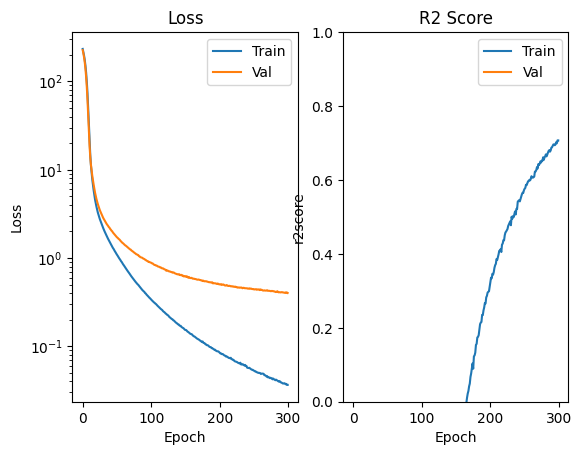

In [188]:
plot_history(history)

In [189]:
gist_df=pd.DataFrame(history.history)
##gist_df.to_csv('history.csv',index=False)
print(gist_df)

           loss        mae     r2_score    val_loss    val_mae  val_r2_score
0    233.450272  15.260676 -1876.560547  226.400421  15.023522  -1171.508789
1    214.451935  14.621530 -1723.763550  207.425247  14.373554  -1073.237915
2    195.483612  13.951036 -1570.981079  187.008133  13.636340   -967.499451
3    174.519257  13.167241 -1402.194214  164.265869  12.761984   -849.719177
4    150.889297  12.217235 -1212.201294  139.147156  11.714619   -719.631470
..          ...        ...          ...         ...        ...           ...
295    0.037800   0.152333     0.696074    0.402828   0.443392     -1.086215
296    0.037064   0.150441     0.702033    0.407086   0.444206     -1.108265
297    0.037409   0.151220     0.699134    0.402132   0.441313     -1.082610
298    0.036427   0.150085     0.707156    0.406086   0.444099     -1.103087
299    0.036451   0.149098     0.707047    0.401201   0.442119     -1.077788

[300 rows x 6 columns]


In [190]:
result = model.evaluate(xtest, ytest)
print(result)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4448 - mae: 0.4404 - r2_score: -1.2251 
[0.4012013077735901, 0.44211891293525696, -1.0777878761291504]
